## Importations et Préparation des Données

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Fonctions d'Activation et de Perte

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def binary_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

## Gradient Descent (GD)

In [3]:
# Implémentation du Gradient Descent (GD)
def train_gd(X, y, lr=0.01, epochs=1000):
    np.random.seed(0)
    n_samples, n_features = X.shape
    W1 = np.random.randn(n_features, 10)
    b1 = np.zeros(10)
    W2 = np.random.randn(10, 1)
    b2 = 0
    losss = []
    
    for epoch in range(epochs):
        # Forward
        Z1 = X.dot(W1) + b1
        A1 = relu(Z1)
        Z2 = A1.dot(W2) + b2
        A2 = sigmoid(Z2).flatten()
        
        # Loss
        loss = binary_cross_entropy(y, A2)
        losss.append(loss)
        # Backward
        dZ2 = A2 - y
        dW2 = A1.T.dot(dZ2[:, None]) / n_samples
        db2 = np.mean(dZ2)
        dA1 = dZ2[:, None].dot(W2.T)
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = X.T.dot(dZ1) / n_samples
        db1 = np.mean(dZ1, axis=0)
        
        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")
    return W1, b1, W2, b2 , losss


## Stochastic Gradient Descent (SGD)

In [4]:
# Implémentation de Stochastic Gradient Descent (SGD)
def train_sgd(X, y, lr=0.01, epochs=10):
    np.random.seed(0)
    n_samples, n_features = X.shape
    W1 = np.random.randn(n_features, 10)
    b1 = np.zeros(10)
    W2 = np.random.randn(10, 1)
    b2 = 0
    losss = []
    
    for epoch in range(epochs):
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        for i in indices:
            xi = X[i:i+1]
            yi = y[i]
            
            Z1 = xi.dot(W1) + b1
            A1 = relu(Z1)
            Z2 = A1.dot(W2) + b2
            A2 = sigmoid(Z2).flatten()
            
            dZ2 = A2 - yi
            dW2 = A1.T.dot(dZ2[:, None])
            db2 = dZ2
            dA1 = dZ2[:, None].dot(W2.T)
            dZ1 = dA1 * relu_derivative(Z1)
            dW1 = xi.T.dot(dZ1)
            db1 = dZ1.flatten()
            
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1
        
        # Évaluer la perte à chaque époque
        Z1 = X.dot(W1) + b1
        A1 = relu(Z1)
        A2 = sigmoid(A1.dot(W2) + b2).flatten()
        loss = binary_cross_entropy(y, A2)
        losss.append(loss)
        print(f"Epoch {epoch}, Loss: {loss:.4f}")
    return W1, b1, W2, b2 , losss


## SGD avec Momentum

In [5]:
# Implémentation de SGD avec Momentum
def train_momentum(X, y, lr=0.01, epochs=100, beta=0.9, batch_size=32):
    np.random.seed(0)
    n_samples, n_features = X.shape
    W1 = np.random.randn(n_features, 10)
    b1 = np.zeros(10)
    W2 = np.random.randn(10, 1)
    b2 = 0
    vW1, vb1, vW2, vb2 = 0, 0, 0, 0
    losss = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(n_samples)
        for i in range(0, n_samples, batch_size):
            idx = indices[i:i+batch_size]
            xi, yi = X[idx], y[idx]
            
            Z1 = xi.dot(W1) + b1
            A1 = relu(Z1)
            Z2 = A1.dot(W2) + b2
            A2 = sigmoid(Z2).flatten()
            
            dZ2 = A2 - yi
            dW2 = A1.T.dot(dZ2[:, None]) / batch_size
            db2 = np.mean(dZ2)
            dA1 = dZ2[:, None].dot(W2.T)
            dZ1 = dA1 * relu_derivative(Z1)
            dW1 = xi.T.dot(dZ1) / batch_size
            db1 = np.mean(dZ1, axis=0)

            # momentum updates
            vW2 = beta * vW2 - lr * dW2
            vb2 = beta * vb2 - lr * db2
            vW1 = beta * vW1 - lr * dW1
            vb1 = beta * vb1 - lr * db1

            W2 += vW2
            b2 += vb2
            W1 += vW1
            b1 += vb1
        
        Z1 = X.dot(W1) + b1
        A1 = relu(Z1)
        A2 = sigmoid(A1.dot(W2) + b2).flatten()
        loss = binary_cross_entropy(y, A2)
        losss.append(loss)
        print(f"Epoch {epoch}, Loss: {loss:.4f}")
    return W1, b1, W2, b2 , losss


## SGD avec Nesterov

In [6]:
# Implémentation de SGD avec Nesterov Accelerated Gradient
def train_nesterov(X, y, lr=0.01, epochs=100, beta=0.9, batch_size=32):
    np.random.seed(0)
    n_samples, n_features = X.shape
    W1 = np.random.randn(n_features, 10)
    b1 = np.zeros(10)
    W2 = np.random.randn(10, 1)
    b2 = 0
    vW1, vb1, vW2, vb2 = 0, 0, 0, 0
    losss = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(n_samples)
        for i in range(0, n_samples, batch_size):
            idx = indices[i:i+batch_size]
            xi, yi = X[idx], y[idx]

            Z1 = xi.dot(W1 + beta * vW1) + b1 + beta * vb1
            A1 = relu(Z1)
            Z2 = A1.dot(W2 + beta * vW2) + b2 + beta * vb2
            A2 = sigmoid(Z2).flatten()

            dZ2 = A2 - yi
            dW2 = A1.T.dot(dZ2[:, None]) / batch_size
            db2 = np.mean(dZ2)
            dA1 = dZ2[:, None].dot(W2.T)
            dZ1 = dA1 * relu_derivative(Z1)
            dW1 = xi.T.dot(dZ1) / batch_size
            db1 = np.mean(dZ1, axis=0)

            vW2 = beta * vW2 - lr * dW2
            vb2 = beta * vb2 - lr * db2
            vW1 = beta * vW1 - lr * dW1
            vb1 = beta * vb1 - lr * db1

            W2 += vW2
            b2 += vb2
            W1 += vW1
            b1 += vb1

        Z1 = X.dot(W1) + b1
        A1 = relu(Z1)
        A2 = sigmoid(A1.dot(W2) + b2).flatten()
        loss = binary_cross_entropy(y, A2)
        losss.append(loss)
        print(f"Epoch {epoch}, Loss: {loss:.4f}")
    return W1, b1, W2, b2 , losss


## Entraînement et Évaluation


--- Gradient Descent ---
Epoch 0, Loss: 0.8954
Epoch 100, Loss: 0.3117
Epoch 200, Loss: 0.2552
Epoch 300, Loss: 0.2283
Epoch 400, Loss: 0.2110
Epoch 500, Loss: 0.1982
Epoch 600, Loss: 0.1881
Epoch 700, Loss: 0.1796
Epoch 800, Loss: 0.1728
Epoch 900, Loss: 0.1668


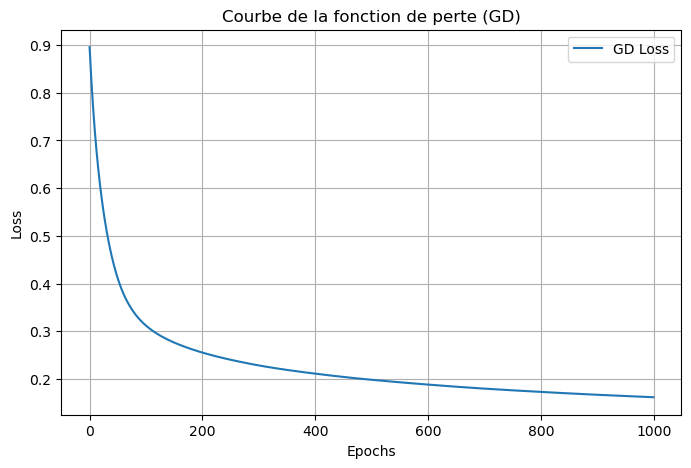

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       100
           1       0.97      0.95      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



In [7]:
# Entraînement et évaluation pour chaque algorithme
from sklearn.metrics import classification_report

# GD
print("\n--- Gradient Descent ---")
W1, b1, W2, b2 , lossss = train_gd(X_train, y_train)
A1 = relu(X_test.dot(W1) + b1)
y_pred = sigmoid(A1.dot(W2) + b2).flatten() > 0.5
# Tracer la courbe de la fonction de perte
plt.figure(figsize=(8,5))
plt.plot(lossss, label="GD Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Courbe de la fonction de perte (GD)")
plt.grid(True)
plt.legend()
plt.show()

print(classification_report(y_test, y_pred))



--- Stochastic Gradient Descent ---
Epoch 0, Loss: 0.1737
Epoch 1, Loss: 0.1381
Epoch 2, Loss: 0.1234
Epoch 3, Loss: 0.1049
Epoch 4, Loss: 0.0940
Epoch 5, Loss: 0.0845
Epoch 6, Loss: 0.0758
Epoch 7, Loss: 0.0667
Epoch 8, Loss: 0.0591
Epoch 9, Loss: 0.0532
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       1.00      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



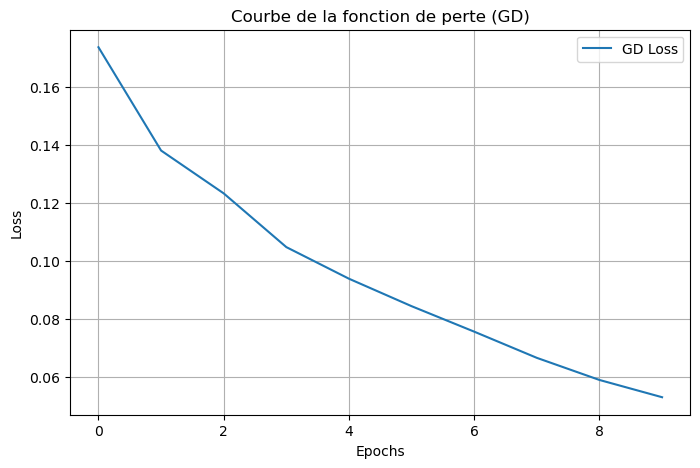

In [8]:

# SGD
print("\n--- Stochastic Gradient Descent ---")
W1, b1, W2, b2, losses = train_sgd(X_train, y_train)
A1 = relu(X_test.dot(W1) + b1)
y_pred = sigmoid(A1.dot(W2) + b2).flatten() > 0.5
print(classification_report(y_test, y_pred))
# Tracer la courbe de la fonction de perte
plt.figure(figsize=(8,5))
plt.plot(losses, label="GD Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Courbe de la fonction de perte (GD)")
plt.grid(True)
plt.legend()
plt.show()



--- SGD avec Momentum ---
Epoch 0, Loss: 0.2487
Epoch 1, Loss: 0.2044
Epoch 2, Loss: 0.1800
Epoch 3, Loss: 0.1636
Epoch 4, Loss: 0.1525
Epoch 5, Loss: 0.1438
Epoch 6, Loss: 0.1359
Epoch 7, Loss: 0.1293
Epoch 8, Loss: 0.1232
Epoch 9, Loss: 0.1182
Epoch 10, Loss: 0.1134
Epoch 11, Loss: 0.1092
Epoch 12, Loss: 0.1054
Epoch 13, Loss: 0.1019
Epoch 14, Loss: 0.0986
Epoch 15, Loss: 0.0956
Epoch 16, Loss: 0.0927
Epoch 17, Loss: 0.0900
Epoch 18, Loss: 0.0873
Epoch 19, Loss: 0.0848
Epoch 20, Loss: 0.0822
Epoch 21, Loss: 0.0799
Epoch 22, Loss: 0.0774
Epoch 23, Loss: 0.0751
Epoch 24, Loss: 0.0729
Epoch 25, Loss: 0.0706
Epoch 26, Loss: 0.0682
Epoch 27, Loss: 0.0661
Epoch 28, Loss: 0.0635
Epoch 29, Loss: 0.0612
Epoch 30, Loss: 0.0593
Epoch 31, Loss: 0.0570
Epoch 32, Loss: 0.0550
Epoch 33, Loss: 0.0531
Epoch 34, Loss: 0.0514
Epoch 35, Loss: 0.0499
Epoch 36, Loss: 0.0483
Epoch 37, Loss: 0.0470
Epoch 38, Loss: 0.0457
Epoch 39, Loss: 0.0445
Epoch 40, Loss: 0.0434
Epoch 41, Loss: 0.0424
Epoch 42, Loss: 0

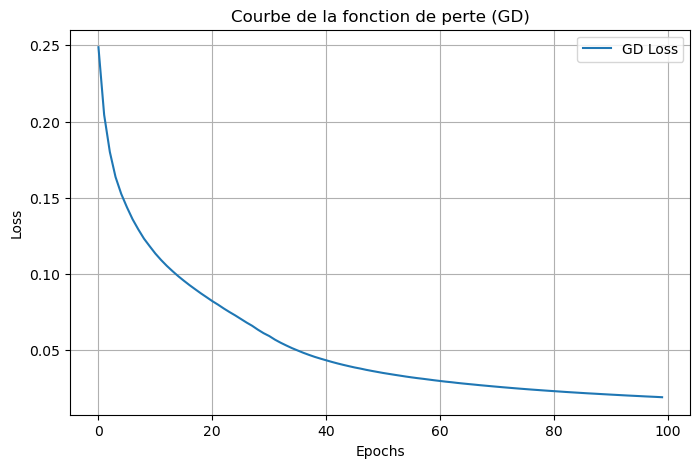

In [9]:

# SGD + Momentum
print("\n--- SGD avec Momentum ---")
W1, b1, W2, b2 ,losses = train_momentum(X_train, y_train)
A1 = relu(X_test.dot(W1) + b1)
y_pred = sigmoid(A1.dot(W2) + b2).flatten() > 0.5
print(classification_report(y_test, y_pred))
# Tracer la courbe de la fonction de perte
plt.figure(figsize=(8,5))
plt.plot(losses, label="GD Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Courbe de la fonction de perte (GD)")
plt.grid(True)
plt.legend()
plt.show()


--- SGD avec Nesterov ---
Epoch 0, Loss: 0.2479
Epoch 1, Loss: 0.2037
Epoch 2, Loss: 0.1800
Epoch 3, Loss: 0.1637
Epoch 4, Loss: 0.1525
Epoch 5, Loss: 0.1438
Epoch 6, Loss: 0.1358
Epoch 7, Loss: 0.1292
Epoch 8, Loss: 0.1231
Epoch 9, Loss: 0.1182
Epoch 10, Loss: 0.1133
Epoch 11, Loss: 0.1091
Epoch 12, Loss: 0.1053
Epoch 13, Loss: 0.1018
Epoch 14, Loss: 0.0985
Epoch 15, Loss: 0.0955
Epoch 16, Loss: 0.0926
Epoch 17, Loss: 0.0899
Epoch 18, Loss: 0.0872
Epoch 19, Loss: 0.0847
Epoch 20, Loss: 0.0821
Epoch 21, Loss: 0.0798
Epoch 22, Loss: 0.0774
Epoch 23, Loss: 0.0750
Epoch 24, Loss: 0.0728
Epoch 25, Loss: 0.0705
Epoch 26, Loss: 0.0682
Epoch 27, Loss: 0.0660
Epoch 28, Loss: 0.0635
Epoch 29, Loss: 0.0612
Epoch 30, Loss: 0.0593
Epoch 31, Loss: 0.0569
Epoch 32, Loss: 0.0549
Epoch 33, Loss: 0.0531
Epoch 34, Loss: 0.0514
Epoch 35, Loss: 0.0498
Epoch 36, Loss: 0.0483
Epoch 37, Loss: 0.0469
Epoch 38, Loss: 0.0456
Epoch 39, Loss: 0.0445
Epoch 40, Loss: 0.0434
Epoch 41, Loss: 0.0423
Epoch 42, Loss: 0

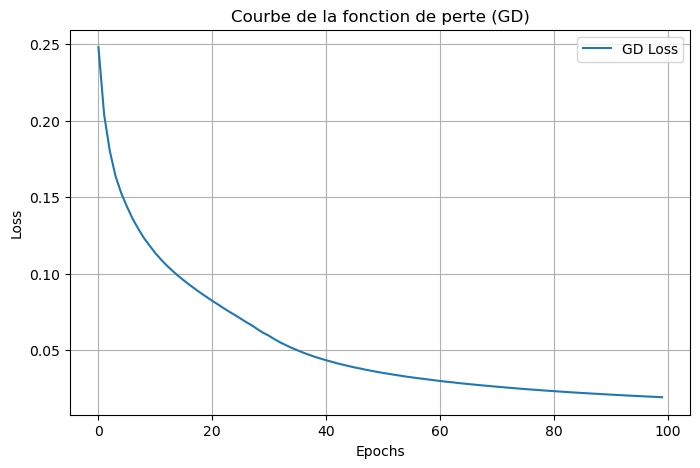

In [10]:

# SGD + Nesterov
print("\n--- SGD avec Nesterov ---")
W1, b1, W2, b2 , losses = train_nesterov(X_train, y_train)
A1 = relu(X_test.dot(W1) + b1)
y_pred = sigmoid(A1.dot(W2) + b2).flatten() > 0.5
print(classification_report(y_test, y_pred))
# Tracer la courbe de la fonction de perte
plt.figure(figsize=(8,5))
plt.plot(losses, label="GD Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Courbe de la fonction de perte (GD)")
plt.grid(True)
plt.legend()
plt.show()

## Optimiseurs : Adagrad, RMSprop, Adam

In [11]:
# Adagrad
def train_adagrad(X, y, lr=0.01, epochs=1000, epsilon=1e-8):
    np.random.seed(0)
    n_samples, n_features = X.shape
    W1 = np.random.randn(n_features, 10)
    b1 = np.zeros(10)
    W2 = np.random.randn(10, 1)
    b2 = 0
    G_W1 = np.zeros_like(W1)
    G_b1 = np.zeros_like(b1)
    G_W2 = np.zeros_like(W2)
    G_b2 = 0
    losses = []
    for epoch in range(epochs):
        Z1 = X.dot(W1) + b1
        A1 = relu(Z1)
        Z2 = A1.dot(W2) + b2
        A2 = sigmoid(Z2).flatten()
        loss = binary_cross_entropy(y, A2)
        losses.append(loss)
        dZ2 = A2 - y
        dW2 = A1.T.dot(dZ2[:, None]) / n_samples
        db2 = np.mean(dZ2)
        dA1 = dZ2[:, None].dot(W2.T)
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = X.T.dot(dZ1) / n_samples
        db1 = np.mean(dZ1, axis=0)
        G_W1 += dW1**2
        G_b1 += db1**2
        G_W2 += dW2**2
        G_b2 += db2**2
        W1 -= lr * dW1 / (np.sqrt(G_W1) + epsilon)
        b1 -= lr * db1 / (np.sqrt(G_b1) + epsilon)
        W2 -= lr * dW2 / (np.sqrt(G_W2) + epsilon)
        b2 -= lr * db2 / (np.sqrt(G_b2) + epsilon)
    return losses


In [12]:
# RMSprop
def train_rmsprop(X, y, lr=0.001, epochs=1000, beta=0.9, epsilon=1e-8):
    np.random.seed(0)
    n_samples, n_features = X.shape
    W1 = np.random.randn(n_features, 10)
    b1 = np.zeros(10)
    W2 = np.random.randn(10, 1)
    b2 = 0
    E_W1 = np.zeros_like(W1)
    E_b1 = np.zeros_like(b1)
    E_W2 = np.zeros_like(W2)
    E_b2 = 0
    losses = []
    for epoch in range(epochs):
        Z1 = X.dot(W1) + b1
        A1 = relu(Z1)
        Z2 = A1.dot(W2) + b2
        A2 = sigmoid(Z2).flatten()
        loss = binary_cross_entropy(y, A2)
        losses.append(loss)
        dZ2 = A2 - y
        dW2 = A1.T.dot(dZ2[:, None]) / n_samples
        db2 = np.mean(dZ2)
        dA1 = dZ2[:, None].dot(W2.T)
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = X.T.dot(dZ1) / n_samples
        db1 = np.mean(dZ1, axis=0)
        E_W1 = beta * E_W1 + (1 - beta) * dW1**2
        E_b1 = beta * E_b1 + (1 - beta) * db1**2
        E_W2 = beta * E_W2 + (1 - beta) * dW2**2
        E_b2 = beta * E_b2 + (1 - beta) * db2**2
        W1 -= lr * dW1 / (np.sqrt(E_W1) + epsilon)
        b1 -= lr * db1 / (np.sqrt(E_b1) + epsilon)
        W2 -= lr * dW2 / (np.sqrt(E_W2) + epsilon)
        b2 -= lr * db2 / (np.sqrt(E_b2) + epsilon)
    return losses


In [13]:
# Adam
def train_adam(X, y, lr=0.001, epochs=1000, beta1=0.9, beta2=0.999, epsilon=1e-8):
    np.random.seed(0)
    n_samples, n_features = X.shape
    W1 = np.random.randn(n_features, 10)
    b1 = np.zeros(10)
    W2 = np.random.randn(10, 1)
    b2 = 0
    m_W1 = np.zeros_like(W1)
    v_W1 = np.zeros_like(W1)
    m_b1 = np.zeros_like(b1)
    v_b1 = np.zeros_like(b1)
    m_W2 = np.zeros_like(W2)
    v_W2 = np.zeros_like(W2)
    m_b2 = 0
    v_b2 = 0
    losses = []
    for epoch in range(1, epochs + 1):
        Z1 = X.dot(W1) + b1
        A1 = relu(Z1)
        Z2 = A1.dot(W2) + b2
        A2 = sigmoid(Z2).flatten()
        loss = binary_cross_entropy(y, A2)
        losses.append(loss)
        dZ2 = A2 - y
        dW2 = A1.T.dot(dZ2[:, None]) / n_samples
        db2 = np.mean(dZ2)
        dA1 = dZ2[:, None].dot(W2.T)
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = X.T.dot(dZ1) / n_samples
        db1 = np.mean(dZ1, axis=0)
        m_W1 = beta1 * m_W1 + (1 - beta1) * dW1
        v_W1 = beta2 * v_W1 + (1 - beta2) * (dW1 ** 2)
        m_b1 = beta1 * m_b1 + (1 - beta1) * db1
        v_b1 = beta2 * v_b1 + (1 - beta2) * (db1 ** 2)
        m_W2 = beta1 * m_W2 + (1 - beta1) * dW2
        v_W2 = beta2 * v_W2 + (1 - beta2) * (dW2 ** 2)
        m_b2 = beta1 * m_b2 + (1 - beta1) * db2
        v_b2 = beta2 * v_b2 + (1 - beta2) * (db2 ** 2)
        m_W1_corr = m_W1 / (1 - beta1 ** epoch)
        v_W1_corr = v_W1 / (1 - beta2 ** epoch)
        m_b1_corr = m_b1 / (1 - beta1 ** epoch)
        v_b1_corr = v_b1 / (1 - beta2 ** epoch)
        m_W2_corr = m_W2 / (1 - beta1 ** epoch)
        v_W2_corr = v_W2 / (1 - beta2 ** epoch)
        m_b2_corr = m_b2 / (1 - beta1 ** epoch)
        v_b2_corr = v_b2 / (1 - beta2 ** epoch)
        W1 -= lr * m_W1_corr / (np.sqrt(v_W1_corr) + epsilon)
        b1 -= lr * m_b1_corr / (np.sqrt(v_b1_corr) + epsilon)
        W2 -= lr * m_W2_corr / (np.sqrt(v_W2_corr) + epsilon)
        b2 -= lr * m_b2_corr / (np.sqrt(v_b2_corr) + epsilon)
    return losses



--- Adagrad ---


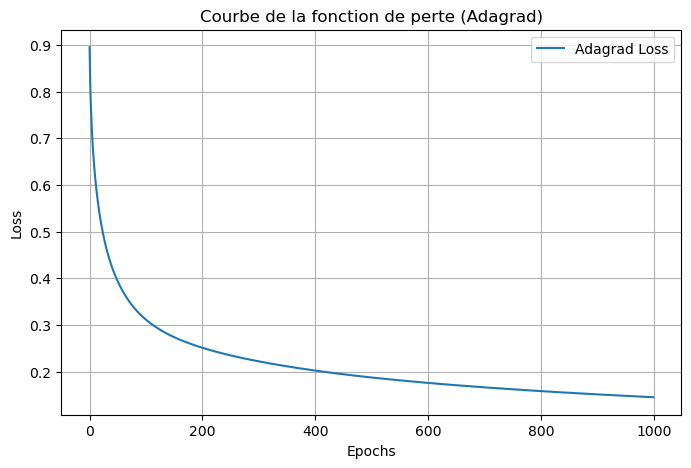

In [14]:
# Adagrad
print("\n--- Adagrad ---")
losses = train_adagrad(X_train, y_train)
W1, b1, W2, b2 = np.random.randn(2, 10), np.zeros(10), np.random.randn(10, 1), 0  # Dummy reinit (losses only returned)
# Pour une évaluation réaliste, modifier train_adagrad pour retourner les poids
plt.figure(figsize=(8,5))
plt.plot(losses, label="Adagrad Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Courbe de la fonction de perte (Adagrad)")
plt.grid(True)
plt.legend()
plt.show()



--- RMSprop ---


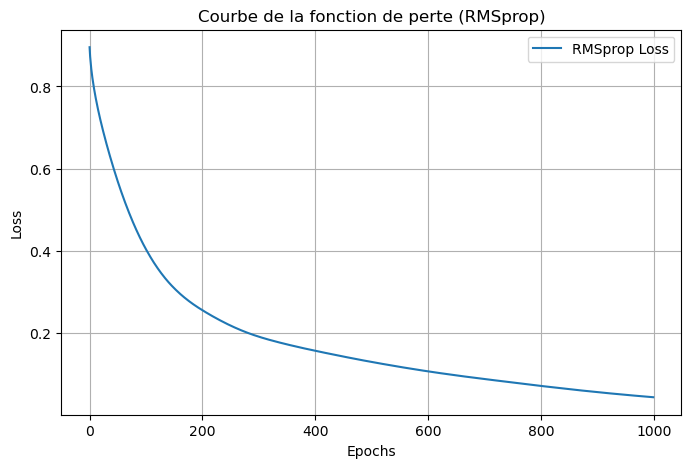

In [18]:
# RMSprop
print("\n--- RMSprop ---")
losses = train_rmsprop(X_train, y_train)
W1, b1, W2, b2 = np.random.randn(2, 10), np.zeros(10), np.random.randn(10, 1), 0  # Dummy reinit
plt.figure(figsize=(8,5))
plt.plot(losses, label="RMSprop Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Courbe de la fonction de perte (RMSprop)")
plt.grid(True)
plt.legend()
plt.show()



--- Adam ---


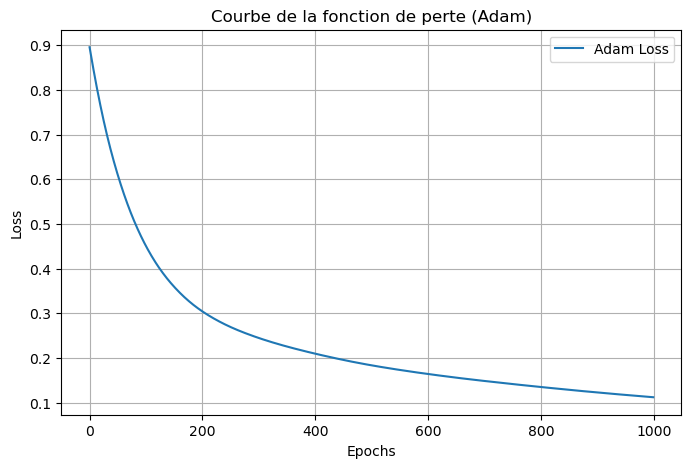

In [16]:
# Adam
print("\n--- Adam ---")
losses = train_adam(X_train, y_train)
W1, b1, W2, b2 = np.random.randn(2, 10), np.zeros(10), np.random.randn(10, 1), 0  # Dummy reinit
plt.figure(figsize=(8,5))
plt.plot(losses, label="Adam Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Courbe de la fonction de perte (Adam)")
plt.grid(True)
plt.legend()
plt.show()
